## TEAM MEMBERS:
Alexandre Vray

Antoine Martin

Germán García

Etienne Chassaing

## Our case study :

Baby yoda has been kidnapped on a planet (almost) full of water. He needs to be rescued by his friend the mandalorian: 

<img src="images/baby_mando.jpg" alt="Drawing" style="width: 500px;"/>

Helped by his Thymio ship and a team of engineers, the mandalorian has to localize the green head of his friend and go to him as quickly as possible while avoiding the obstacles on the way. One also need to be sure that nothing will deviate him from his goal by localizing him as frequently and precisely as possible.

<img src="images/mando_thymio.jpg" alt="Drawing" style="width: 500px;"/>

The following sections will explain all the elements we used to make the mandolarian fulfill his mission.

# Import Libraries

In [1]:
import cv2 as cv
import time
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
# our functions:
from vision import Vision
from a_star_and_helper import *
from graphs_plots import*
from controller import*


In [2]:
# Thymio connection:
import tdmclient.notebook
from tdmclient import ClientAsync, aw
client = ClientAsync()
%matplotlib inline

In [3]:
client.process_waiting_messages()
node = client.nodes[0]
node

Node 98af70f5-99db-47b6-9af1-068c8de06652

# Initialization
Take a first picture of the map and turn off the leds of the Thymio:

In [4]:
img = Vision()

In [278]:
aw(node.lock())

circle = {
    "leds.circle": [0,0,0,0,0,0,0,0],
}

aw(node.set_variables(circle))
aw(node.unlock())

# Mapping ( vision.py file )


Here the objective is to use the camera to identify obstacles, arrivals and initial position/orientation of the thymio. To do so, a Vision() class was created with 2 main methods (Look at the vision.py file) :
- The first method mapping() used to differentiate the different colors from the captured picture. And then we assume the obstacles to be blue (to imitate lakes) and the goal to be green (Grogu/Baby Yoda). The arrival is identified by contour identification. One verify there is only one green patch and if so, one can identify his contours and find the center of Baby Yoda.

- The second method find_thymio() is here to identify where the Thymio is on the picture and what his orientation is. To do so we put some colored stickers on the Thymio. Two purples on the front and a yellow on the head of the mandalorian. The method used is image tracking by using a template of a yellow and a purple dot. This method is not robust against orientations but in case these are circles, it's not dependent of orientation.

Finally, we show below on the left the picture taken with the identification of the important points. The right figure is the map (obstacle = 1, free space = 0) on which we had some important points.
- The yellow and blue points are those identified previously on the thymio, and a new red point is calculated to be the position of the thymio. Because of the perspective of the mandalorian (a 7cm lego statue on the thymio), we need to compute the real position of the thymio center.
- The green point represents Grogu/Baby-Yoda goal


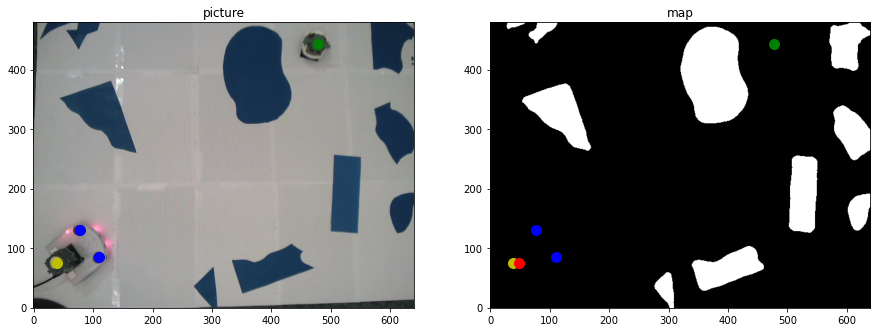

In [279]:
#all img variables are save into the class
img.mapping() # take a picture => identify obstacles and arrival
img.find_thymio() #identify the thymio position and goal

plot_obstacles_arrival(img)


# Path Planning (a_star_and_helper.py)

Now we have a first map of the environment, we need to find a path from the starting position to the baby yoda goal.
The planning algorithm was chosen to be **$A^*$** for the following reasons :
- It works for various type of maps
- It does not need any edge detection
- It finds an optimal solution to our problem
- The objective function can be easily modified

Here is how we will use **$A^*$** in our problem: 

The vision provided a map of the obstacle which gives the occupied cells in which the robot can not go. The map is then rescaled to allow a quicker convergence of **$A^*$** without loosing too much precision. We divide the initial map by a scale factor. In the following example, the map is rescaled to size 60x80, which mean every cell is approximately 1.2cm*1.2cm. 

Then, one have to consider the size of the Thymio to avoid findind a path too close along the blue zones. The blue zones are thus inflated with a convolution filter in a new map to take into account the Thymio size. The `val_fit` parameter allows to control the size of the filter. This new map is not used as on obstacle map, but rather used as a cost map in the **$A^*$** algorithm which has been modified to do so.
Therefore, the area arounds to the obstacles are not a no-go zone but rather a high cost zone. It allows to have softer constraints rather than overconstraining our problem. Thus, if a path is at the limit to be large enough fot the Thymio to pass, this one could be chosen by the **$A^*$** algorithm by keeping the Thymio well centered.
This implementation is subject to 2 parameters, the value of the filter and the weight of the cost in **$A^*$**, it need to be tuned for the desired case. The value of the filter is chosen below, in our case the weight of the cost was chosen to be high to have the Thymio well centered (see line **142** of **A_star_and_helper.py**).

### Rescaling and create cost map by inflating the obstacles

The **prepare_map()** function resizes the map and creates an inflated map to be used as cost map, using the `val_fit` value. This value is set between 15 and 20, wich is between 18 and 24 cm. The filter will inflate the obstacle up to half of the value of the `val_fit` value. The obstacles are thus inflated between 9 to 12 cm, which allows our 10 cm wide Thymio to pass.

In [280]:
N,M = np.shape(img.obstacles) #Size of original map
scale_factor = int(N/60) # divide the map by 60

sized_map, inflated_map = prepare_map(img.obstacles, val_filt=15, scale_factor=scale_factor)

# Display the map

Based on the captured picture, the map is resized and displayed:

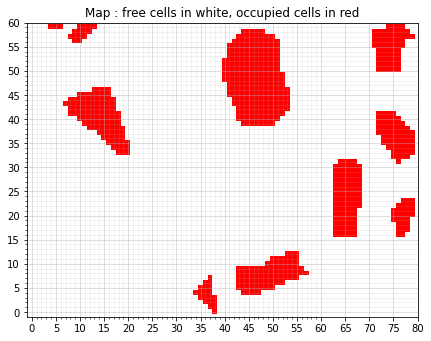

In [281]:
#Creating the grid
max_val_x = np.size(sized_map[1,:]) # Size of the map
max_val_y = np.size(sized_map[:,1])

fig, ax = create_empty_plot(max_val_x,max_val_y)

# Displaying the map
cmap = colors.ListedColormap(['white', 'red']) # Select the colors with which to display obstacles and free cells

ax.imshow(sized_map, cmap=cmap)
plt.title("Map : free cells in white, occupied cells in red");


# Display the cost map
The obtained cost map is displayed below. The presence of a non zero cost may be sometimes hard to see, the second plot show a binary value to see where a non zero cost is present.

To well understand what is happening, one can look at the space between the obstacles in the range x = [25,35] and y = [35,45]. In this zone the path is 10 pixel wide, which is 12 cm. The Thymio can pass but need to stick to the center. The continuous cost map is creating a cost comparable to a potential well, the best path to take is to follow the center of the valley:

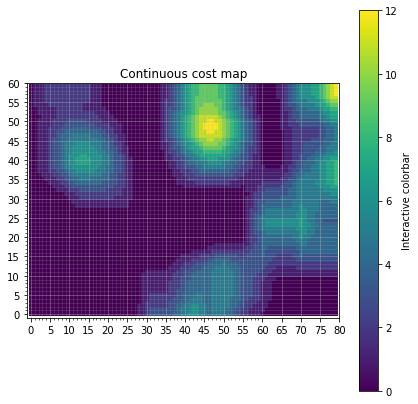

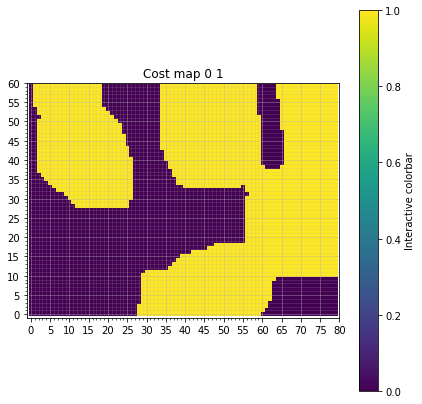

In [282]:
plot_inflated_map(fig,inflated_map,max_val_x,max_val_y)

### A* algorithm computation
$A^*$ is using the start and goal position obtained by the vision, the obstacle map also obtained by vision and the cost map defined and created above:

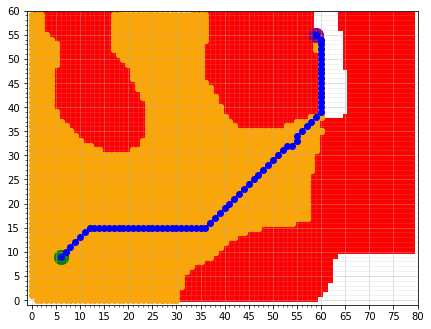

In [283]:
# Define the start_point and end goal
start_point = (int(img.thymio_pos[0]//scale_factor),int(img.thymio_pos[1]//scale_factor))
arrival = (int(img.arrival[0])//scale_factor,int(img.arrival[1]//scale_factor))

# use of A*, inflated map is the cost map, visited nodes is used for plotting
path, visitedNodes = A_Star(start_point, arrival, sized_map, inflated_map)
path = np.array(path).reshape(-1, 2).transpose()
visitedNodes = np.array(visitedNodes).reshape(-1, 2).transpose()

# Displaying the map
plot_A_star(start_point,arrival,path,visitedNodes,sized_map,inflated_map,max_val_x,max_val_y)

- **NOTE 1**: In orange are the explored cells by the algorithm
- **NOTE 2**: This visualization is a bit confusing since it shows the inflated obstacles as no-go zone, this a plot mismatch, here is an example of how should the obstacles (in red) and the non zero cost (in pink) be plotted on a simpler map :

<img src="images/pink.png" alt="Drawing" style="width: 400px;"/>

Now the path was generated, the Thymio has to follow it in the map coordinates. We first need to convert it in millimeters and then keep only a few points of the path.

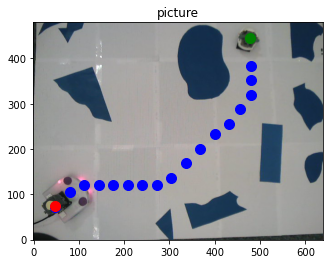

In [284]:
#Thymio.size => true physical distance between purple points on the thymio
#img.thymio_size => distance in pixels between this 2 points on the picture

img2mm = Thymio.size/img.thymio_size #scale factor from a picture to mm
map2mm = Thymio.size*scale_factor/img.thymio_size #scale factor from the map to mm

#from a_star_and_helper.py this function gives us few points of the pass with the coordinates in mm
goals = find_goals(path,map2mm)

#Here we show the goals on the picture
plt.imshow(img.map, cmap='gray',origin='lower'), plt.title('picture')
plt.plot(img.arrival[0],img.arrival[1],"og",markersize=10)
for goal in goals:
    plt.plot(goal[0]/img2mm,goal[1]/img2mm,"ob",markersize=10)
plt.plot(img.thymio_pos[0],img.thymio_pos[1],"or",markersize=10)
    

# Local Avoidance

Local avoidance is implemented directly on the thymio (offline mode). The idea is to let the thymio change his velocity in the case he finds a hard obstacle. That's why we created an event on the local thymio timer with a period set to 10 ms. Different variables are used in this function and are presented below:
- stop_avoidance : this is a boolean activated when the thymio is closed to the end objective, because our objective is a 3D lego statue and of course we don't want to avoid it. Hence we deactivate the local avoidance at the end of the path.
- state : this variable represent the fact that the thymio has detected an obstacle or not. If yes, state = 1 during 2 seconds to let the thymio have enough time step itself aside from the obstacle.
- time avoidance : represent the time since the state is equal to 1
- avoid_left/avoid_right : represent the difference speed apply of each wheel depending on obstSpeedGain and sensors measurements

In [285]:
await tdmclient.notebook.start()

In [286]:
%%run_python
stop_avoidance = 0 #0 during the simulation// 1 near the arrival to not avoid it

obstSpeedGain = [5, 10, -10, -10, -5] #/100 gains used with front proximity sensors 0..4

obstThrL = 10      # low obstacle threshold to switch state 1->0
obstThrH = 20      # high obstacle threshold to switch state 0->1
state = 0          # 0=gradient, 1=obstacle avoidance

time_avoidance = 0 # time during which state = 1

timer_period[0] = 5  # 5ms sampling time

@onevent 
def timer0():
    #define some global variables needed for local avoidance
    global time_avoidance, prox_ground_delta, prox_horizontal, obstSpeedGain
    global motor_left_speed, motor_right_speed, motor_left_target, motor_right_target
    global avoid_left, avoid_right
    global state

    spLeft = 0
    spRight = 0 
    if not stop_avoidance:
        time_avoidance += 10 #10 ms increase time at each timer step 
        
        #lecture of the horizontal sensors
        obst = [prox_horizontal[0], prox_horizontal[1],prox_horizontal[2],prox_horizontal[3],prox_horizontal[4]]

        if state == 0: 
            # switch from goal tracking to obst avoidance if obstacle detected
            near_obstacle = (obst[0] > obstThrH) or (obst[1] > obstThrH)\
                             or (obst[2] > obstThrH) or (obst[3] > obstThrH) or (obst[4] > obstThrH)
            if near_obstacle:
                #initialize avoidance
                state = 1
                time_avoidance = 0
                avoid_left = 0
                avoid_right = 0
                for i in range(5):
                    avoid_left += prox_horizontal[i] * obstSpeedGain[i] // 100
                    avoid_right += prox_horizontal[i] * obstSpeedGain[4 - i] // 100  
        elif state == 1:
            far_obstacle = (obst[0] < obstThrL) or (obst[1] < obstThrL)\
                             or (obst[2] < obstThrL) or (obst[3] < obstThrL) or (obst[4] < obstThrL)
            #avoidance instructions
            if time_avoidance<1500:
                spLeft +=  avoid_left
                spRight +=  avoid_right
            elif time_avoidance<3000:
                spLeft = 200
                spRight = 200
            elif far_obstacle:
                state = 0
                spLeft = 0
                spRight = 0
            else:
                time_avoidance = 0

            motor_left_target = spLeft
            motor_right_target = spRight

In [287]:
await tdmclient.notebook.stop()

# Run

Here is the main function of the project, time to control our Thymio ! 

To do so we start by "**locking**" the thymio to this Jupyter Notebook and then initialize an instance of the class Thymio. This instance represents the state of our Thymio.

In [288]:
aw(node.lock()) #lock thymio

Node 98af70f5-99db-47b6-9af1-068c8de06652

In [289]:
### Initialization of the thymio class (look at the class in controller.py file) ###
thy = Thymio(goals[0,0],goals[1,0],img.thymio_angle) #set position and orientation

# Other parameters need in the main function #
skip_ok = True #True : thymio allow to skip some goals (if he find an obstacle)
               #False : not allowed (thymio has already skip some goals)

nb_error_thymio = 0 #Number of periods the thymio has not be detected by the camera

pos = np.array([[goals[0,0],goals[1,0]]]) #array to save the thymio positions along time
img_pos = np.array([[goals[0,0],goals[1,0]]]) 
kalman_pos = np.array([[goals[0,0],goals[1,0]]])

total_time = 0 #time of simulation

In the followinf function, we initialized the current goal to the first one of the list "goals", and if the thymio is close enough from this current goal, it goes to the next one.

Concidering only one goal, at each loop the thymio control law change depending on the thymio position compare to the current goal. The funtion Control() is defined in the `controller.py` file. Then we capture a picture every 2 loops and try to identify the thymio. Three cases occur :
- The thymio is not identified : hence it continues his way without a Kalman update, using only odometry as a mean to estimate position 
- The thymio has been kidnapped (thymio not identify during more than 1.5s) but is now found again : in this case we do a re-planning of the path and thymio restart by folowing this new path
- The thymio has been identified and not kidnapped : Here the position of thymio is updated with the kalman filter 

Too talk about the function "Control(thy,dist,alpha,node)", it implement a basic Proportional controller with saturation. i.e. there is a position error "dist" and an orientation error "alpha" to reach the goal. First a proportionnal control is done on the orientation until it the orientation error is small enough (<5°). Then the proportianal gain considering the distance is added. However the wheels speed are limited to make sure the asked task is feasable. Look at the function in the file `controller.py`.

error identification thymio
error identification thymio
error identification thymio
error identification thymio


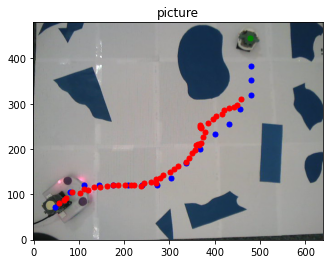

In [290]:
#start the plot
plt.imshow(img.map, cmap='gray',origin='lower'), plt.title('picture') 
plt.plot(img.arrival[0],img.arrival[1],"og",markersize=5)

next_total_time = 2*thy.motors.h #take a picture 2 times less than the frquency of thymio

i = 0
while i < len(goals):
    goal = goals[i] #set the current goal
    plt.plot(goal[0]/img2mm,goal[1]/img2mm,"ob",markersize=5) #plot current goal
    i += 1

    check_remove_avoidance(goal,goals,node) #send to thymio if the local avoidance need to be remove or not
    
    traj = diff_point(thy.pos,goal)
    dist = np.linalg.norm(traj) #distance to current goal
    alpha = norm_angle(np.arctan2(traj[1],traj[0])-thy.theta)
    
    while(dist>80): 
        start = time.time()
        Control(thy,dist,alpha,node) #control of thymio wheels
            
        total_time += thy.motors.h #time of a loop
        if(total_time>next_total_time):
            next_total_time += 2*thy.motors.h # next picture in 2 loops
            img.find_thymio() #take a picture

            if(not img.thymio_error): #thymio found
                if(nb_error_thymio >= 5): #thymio found after kidnapping => replanning
                    nb_error_thymio = 0 # reset error counter
                    print("replanning")
                    start_point = (int(img.thymio_pos[0]//scale_factor),int(img.thymio_pos[1]//scale_factor))
                    path, visitedNodes = A_Star(start_point, arrival, sized_map, inflated_map)
                    path = np.array(path).reshape(-1, 2).transpose()
                    goals = find_goals(path,map2mm)
                    i = 0
                    break
                else: #no kidnapping => estimate position from the new picture
                    nb_error_thymio = 0 # reset error counter
                    x = img.thymio_pos[0]*img2mm
                    y = img.thymio_pos[1]*img2mm
                    thy.new_pos([x,y],img.thymio_angle) #use kalman filter to update the thymio position
                    plt.plot(img.thymio_pos[0],img.thymio_pos[1],"or",markersize=5)
                    img_pos = np.append(img_pos,np.array([[x,y]]),axis=0)
                    kalman_pos = np.append(kalman_pos,np.array([[thy.pos[0],thy.pos[1]]]),axis=0)
                
                 
            else:
                nb_error_thymio += 1
        
        ### update the difference between the thymio new position and the current goal
        traj = diff_point(thy.pos,goal)
        dist = np.linalg.norm(traj) #distance to the current goal
        alpha = norm_angle(np.arctan2(traj[1],traj[0])-thy.theta)
        pos = np.append(pos,np.array([[thy.pos[0],thy.pos[1]]]),axis=0) #save the thymio position
        
        time2wait = thy.motors.h-(time.time()-start) #be sure that the loop duration = thymio period
        # if (time2wait<-thy.motors.h/5):
        #     print("error, computation time is too long")
        if(thy.true_thymio and time2wait>0):
            time.sleep(thy.motors.h-(time.time()-start))
                


### Goal achieved, end of simulation

In [291]:
#switch on circle leds for estethic
circle = {
    "leds.circle": [32,32,32,32,32,32,32,32],
}
aw(node.set_variables(circle))

#stop thymio
thy.setSpeed(0,0,node)

Below is a plot of the positions identified by the camera (blue points) and the one resulting from the kalman filter only when a picture is taken (red points).
One can note that we observe a very little variance between them.


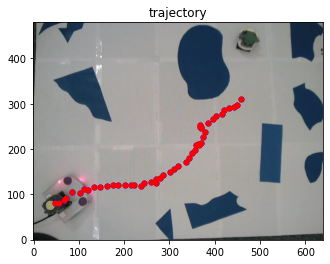

In [292]:
#graph of the positions resulting from kalman filter
plt.imshow(img.map, cmap='gray',origin='lower'), plt.title('trajectory')
for point in img_pos:
    plt.plot(point[0]/img2mm,point[1]/img2mm,"ob",markersize=5)
for point in kalman_pos:
    plt.plot(point[0]/img2mm,point[1]/img2mm,"or",markersize=5)

In [293]:
aw(node.unlock())

# Reaching the goal
If our Thymio did not run out of battery during the way, the mandalorian now have reached his goal:

<img src="images/mando_goal.jpg" alt="Drawing" style="width: 500px;"/>

Two examples are given in the backup videos folder, "`map_1_compressed`" and "`map_2_compressed`" without local voidance.

# Example with obstacle avoidance
The Thymio is also able to avoid any bounty hunter on the path:

<img src="images/obstacle.png" alt="Drawing" style="width: 500px;"/>

The example is given in the backup videos folder as "`map_2_obstacle_compressed`".

# Example of Thymio kidnapping
The mandalorian can still reach his goal even when kidnapped:

<img src="images/kidnap.png" alt="Drawing" style="width: 500px;"/>

The example is given in the backup videos folder "`map_2_kidnapping_compressed`".

Note: All the plots of each experiments are given in the "`Experiments and plots`" folder, sorted by case. The image showing the camera capture the planned path are the most relevant images (look at files `img_1.png`)

# Further implementation

Some further improvement could be done to the project to make the system more autonomous. Some of them are proposed below :
# Replanning

In the case of an obstacle blocking the all path, one could also replan a path by adding an obstacle to the map. The function replanning was implemented but not used in this context, it takes as an input the map, the location of the Thymio and the estimated position of the obstacle. The position of the obstacle can be estimated using proximity sensors, Thymio position and orientation. It size can be either arbitrary to ensure a replanning or estimated by the Thymio.

Here is a simulation example were the new obstacle is a line blocking the path.
Old path in is in blue and new one in green.

<img src="images/replanning" alt="Drawing" style="width: 500px;"/>

Please note the chosen path in this case would be dependant of the weight of the cost map chosen above. For a low cost, the replaned path will turn around this obstacle, for a higher cost, another path is chosen.

# More robust Motion Controller
- The current controller is working in 2 steps:
    1. Align with the new target by rotating
    2. go forward to the aligned target
- This method has some drawbacks, such as:
    - slower because the Thymio is not getting closer to the robot during the first step (only rotation)
    - is even slower in presence of disturbances, the can easily get unaligned even though it was a step before, the Thymio then must re-execute the first step
- To tackle those disadvantages, one could implement on the Thymio a full P controller trying to minize the difference between the target state variables (x, y, θ) with the current state variables in a smooth way
- You can have a look at the file `controller_future.py` for more info about the implementation
- The position estimator (Kalman filter) works pretty the same as the one used in the live demo

## Simulations
- For testing purpose, it was important to insure the P Controller and the Kalman filter are robust against noise of the Camera and Thymio
- The vision part output to the position estimator a measure of the robot location and angle
- The vision output was simulated by adding random noise to the real position, thus enabling the ability to test the robustness of the Position Estimator
- Below are 2 code cell simulation of the P Controller with 1 and 6 goals

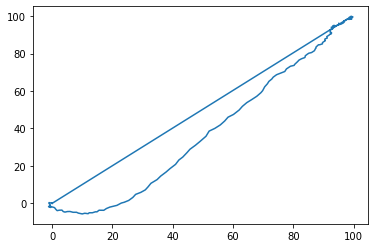

In [294]:
import matplotlib.pyplot as plt
import controller_future as ctrl
import math_util
import numpy as np
import math
import random

pos = math_util.Coord(0.0, 0.0, -math.pi/2);
goal = math_util.Coord(100.0, 100.0, 0.0);
T_sim = 100; # in seconds
step_i = 0;
step_N = (int)(T_sim / ctrl.Motors.T);
pos_histX = [0.0] * step_N;
pos_histY = [0.0] * step_N;
pos_histTheta = [0.0] * step_N;
ctrl.setSpeed(0,0, False);
P = np.array([[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]);
err = math_util.Coord(0.0, 0.0, 0.0);
stable = 0;
while stable < 10:
    if (err.length() > 5) or (err.theta > 0.1):
        stable = 0;
    else:
        stable += 1;
    pos_histX[step_i] = pos.x;
    pos_histY[step_i] = pos.y;
    pos_histTheta[step_i] = pos.theta;
    camera_pos_estimate = math_util.Coord(pos.x + random.random()*2-1, pos.y + random.random()*2-1, pos.theta + random.random()*0.1-0.05);   
    pos, P = ctrl.KalmanFilter(True, pos, P, camera_pos_estimate);
    err = ctrl.Error(pos, goal);
    ctrl.setSpeed(*ctrl.ControllerP(err), False);
    step_i = step_i + 1;

plt.plot(pos_histX, pos_histY);
plt.show();

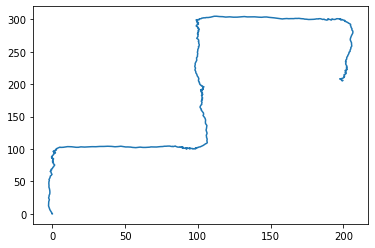

In [295]:
pos = math_util.Coord(0.0, 0.0, math.pi/2);
goals = np.array([math_util.Coord(0.0,   100.0, 0.0),
                  math_util.Coord(100.0, 100.0, 0.0),
                  math_util.Coord(100.0, 200.0, 0.0),
                  math_util.Coord(100.0, 300.0, 0.0),
                  math_util.Coord(200.0, 300.0, 0.0),
                  math_util.Coord(200.0, 200.0, 0.0)]);
T_sim = 150; # in seconds
pathstep_N = len(goals);
step_i = 0;
pathstep_i = 0;
step_N = (int)(T_sim / ctrl.Motors.T);
pos_histX = [0.0] * step_N;
pos_histY = [0.0] * step_N;
P = np.array([[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]);

# While there exist still points to reach on the path
while pathstep_i < pathstep_N:
    # While the position is not within 5mm around the target 
    while ((goals[pathstep_i] - pos).length() > 5) and step_i < step_N:
        pos_histX[step_i] = pos.x;
        pos_histY[step_i] = pos.y;
        camera_pos_estimate = math_util.Coord(pos.x + random.random()*2-1, pos.y + random.random()*2-1, pos.theta + random.random()*0.1-0.05);   
        pos, P = ctrl.KalmanFilter(True, pos, P, camera_pos_estimate);
        err = ctrl.Error(pos, goals[pathstep_i]);
        ctrl.setSpeed(*ctrl.ControllerP(err), False);
        step_i = step_i + 1;
    pathstep_i = pathstep_i + 1;
    
plt.plot(pos_histX[:step_i], pos_histY[:step_i]);
plt.show()

# Conclusion :

We have succeeded in helping the mandalorian complete his mission.

As a quick summary of the project, we were able to achieve this by first successfully identifying the different obstacles as well as the thymio's orientation and position with the mapping methods explained above in the `Mapping` part.

Next, we proceeded by implementing the **$A^*$** algorithm seen in class to find the optimal path using a cost function taking in account the distance to obstacles (calculated by inflating obstacles with convolution filter) and Thymio's size, thus creating soft constraints.

Subsequently, we implemented position control and an estimator to control the motion of the thymio while minimizing the error with help of the simulations.

Finally, we implemented the local avoidance of obstacles such that the Thymio can change his velocity when encountering obstacle.

Additionally from the subjects seen in class, we considered the project planning and team building sessions extremely important for the implementation of this mission, as we were able to fully define the desired outlook of the project, which allowed us to work swiftly the following weeks and communicate effectively.
